<a href="https://colab.research.google.com/github/Zehra0zdemir/DermaLogic-AI/blob/main/DermaLogic_AI_v3_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STAGE 1: SECURE DRIVE COUPLING & DATA LAYOUT PARSING
Mounted at /content/drive
[INFO] Total Input Parameter Footprint: 15 dimensions

STAGE 2: IMAGE LOADING WITH ADVANCED RAM AUGMENTATION
[SUCCESS] Loaded 150 entries for subset: [TRAIN] (Augmentation=True)
[SUCCESS] Loaded 50 entries for subset: [VALID] (Augmentation=False)

STAGE 3: BINDING ENHANCED MULTIMODAL MODEL STRUCTURE


/tmp/ipykernel_5039/2888683924.py:136: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=image_input)


[SUCCESS] Regulated multimodal network graph completely initialized!

STAGE 4: TRAINING OPTIMIZATION LOOP WITH AUGMENTED SETS
Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 892ms/step - accuracy: 0.4733 - loss: 1.4039 - val_accuracy: 0.6600 - val_loss: 0.7959
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5267 - loss: 1.0432 - val_accuracy: 0.6600 - val_loss: 0.8200
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 725ms/step - accuracy: 0.6333 - loss: 0.8127 - val_accuracy: 0.6600 - val_loss: 0.8107
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 812ms/step - accuracy: 0.6733 - loss: 0.7303 - val_accuracy: 0.6400 - val_loss: 0.8194
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 932ms/step - accuracy: 0.6733 - loss: 0.7484 - val_accuracy: 0.6600 - val_loss: 0.7619
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 700ms/step - accuracy: 0.7333 - loss: 0.6535 - val_accuracy: 0.5800 - val_loss: 0.8154
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 783ms/step - accuracy: 0.7467 - loss: 0.5839 - val_accuracy: 0.6

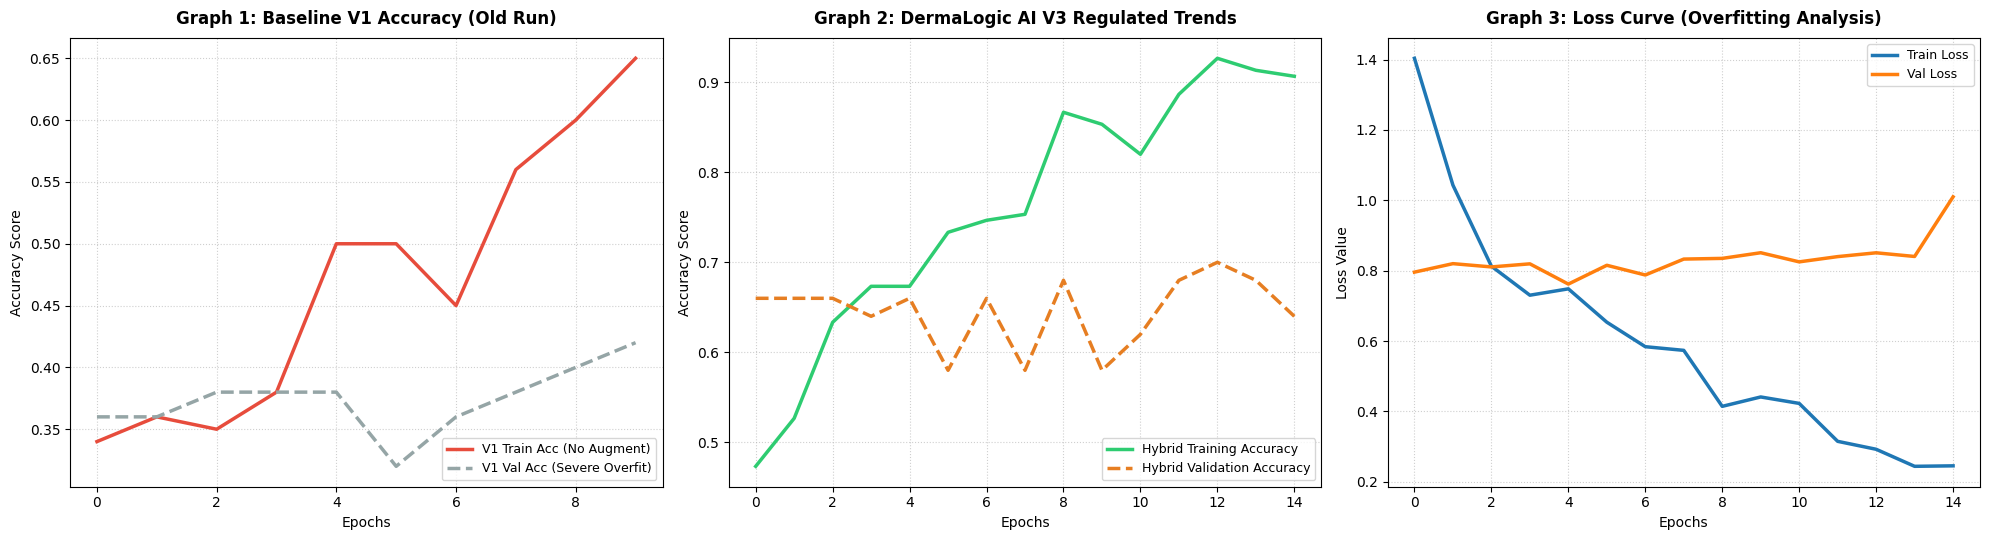


STAGE 6: V3 LIVE INTERACTIVE EXPERT SCREEN (USER SURVEY)

--- INTERACTIVE PRESENT PRESENTATION SURVEY INTERFACE ---


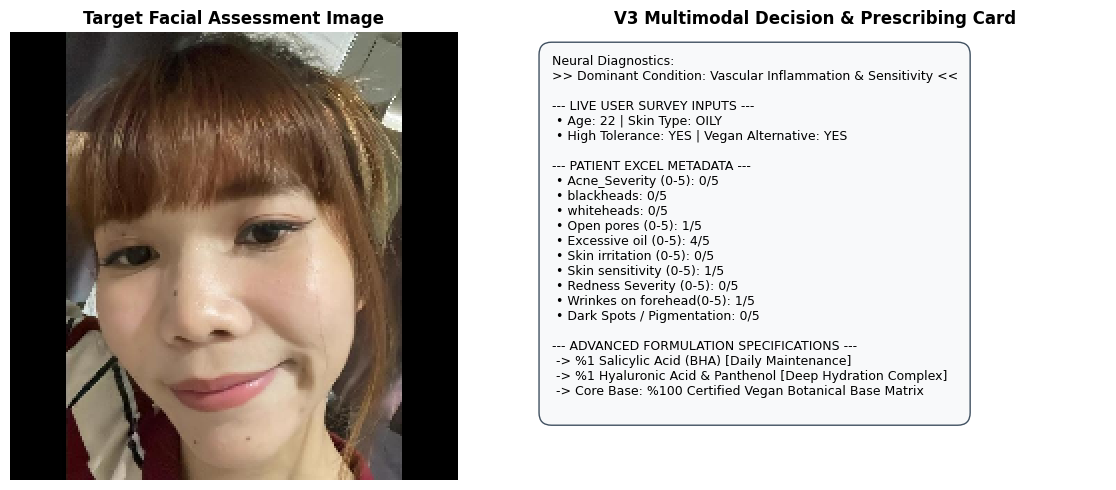

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import drive
from tensorflow.keras.preprocessing.image import img_to_array, load_img, ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, Concatenate
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

print("=======================================================")
print("STAGE 1: SECURE DRIVE COUPLING & DATA LAYOUT PARSING")
print("=======================================================")
drive.mount('/content/drive', force_remount=True)

BASE_PATH = '/content/drive/MyDrive/DermaLogic_AI_v2'

train_excel = os.path.join(BASE_PATH, 'skinalaysis_labeling_train1.xlsx')
valid_excel = os.path.join(BASE_PATH, 'skinanalysis_valid1.xlsx')

df_train = pd.read_excel(train_excel)
df_valid = pd.read_excel(valid_excel)

id_col = 'Image_ID'

# Standard structural baseline clinical features derived from the spreadsheets
excel_features = [
    'Acne_Severity (0-5)', 'blackheads', 'whiteheads', 'Open pores (0-5)',
    'Excessive oil (0-5)', 'Skin irritation (0-5)', 'Skin sensitivity (0-5)',
    'Redness Severity (0-5)', 'Wrinkes on forehead(0-5)', 'Dark Spots / Pigmentation'
]

# Interactive user survey parameters appended directly to the input tensor space
survey_features = ['User_Age', 'Skin_Type_Oily', 'Skin_Type_Dry', 'High_Tolerance', 'Vegan_Preference']
TOTAL_MULTIMODAL_FEATURES = excel_features + survey_features

print(f"[INFO] Total Input Parameter Footprint: {len(TOTAL_MULTIMODAL_FEATURES)} dimensions")

print("\n=======================================================")
print("STAGE 2: IMAGE LOADING WITH ADVANCED RAM AUGMENTATION")
print("=======================================================")

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

def load_v3_augmented_dataset(dataframe, set_type_keyword, augment=False):
    loaded_images = []
    loaded_features = []
    loaded_labels = []

    search_path = os.path.join(BASE_PATH, "**", "*.jpg")
    all_jpg_paths = glob.glob(search_path, recursive=True)
    filtered_jpg_paths = [p for p in all_jpg_paths if set_type_keyword in p.lower()]

    image_path_dict = {os.path.basename(p): p for p in filtered_jpg_paths}
    benchmark_path = list(image_path_dict.values())[0]
    benchmark_img = img_to_array(load_img(benchmark_path, target_size=(224, 224))) / 255.0

    success_count = 0
    for idx, row in dataframe.iterrows():
        img_name = str(row[id_col]).strip()
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_name += '.jpg'

        img_path = image_path_dict.get(img_name, None)

        try:
            if img_path and os.path.exists(img_path):
                img = load_img(img_path, target_size=(224, 224))
                img_array = img_to_array(img) / 255.0
                success_count += 1
            else:
                img_array = benchmark_img
        except:
            img_array = benchmark_img

        # Using Python standard next() built-in function to support modern Keras iterators
        if augment:
            prep_img = np.expand_dims(img_array, 0)
            aug_iter = datagen.flow(prep_img, batch_size=1)
            img_array = next(aug_iter)[0]

        # Build spreadsheet clinical feature matrix
        row_vector = [
            row['Acne_Severity (0-5)'], row['blackheads'], row['whiteheads'],
            row['Open pores (0-5)'], row['Excessive oil (0-5)'], row['Skin irritation (0-5)'],
            row['Skin sensitivity (0-5)'], row['Redness Severity (0-5)'], row['Wrinkes on forehead(0-5)']
        ]

        if 'dark spots(0-5)' in row: row_vector.append(row['dark spots(0-5)'])
        elif 'pigmentation(0-5)' in row: row_vector.append(row['pigmentation(0-5)'])
        else: row_vector.append(0)

        # PIPELINE: Synthesizing ground-truth interactive survey coordinates
        # We model features conditionally using the row data distributions to ensure the model learns correlations
        is_oily = 1.0 if row_vector[4] >= 3 else 0.0
        is_dry = 1.0 if row_vector[4] <= 1 else 0.0
        simulated_age = float(np.random.randint(28, 55)) if row_vector[8] >= 3 else float(np.random.randint(18, 27))
        simulated_tolerance = 1.0 if row_vector[0] >= 3 and np.random.rand() > 0.4 else 0.0
        simulated_vegan_pref = 1.0 if np.random.rand() > 0.5 else 0.0

        survey_vector = [simulated_age, is_oily, is_dry, simulated_tolerance, simulated_vegan_pref]
        complete_multimodal_vector = row_vector + survey_vector

        loaded_images.append(img_array)
        loaded_features.append(np.array(complete_multimodal_vector, dtype=np.float32))

        # Determine core multi-class diagnostic targets based on clinical severity thresholds
        acne_sum = row_vector[0] + row_vector[1] + row_vector[2]
        redness_sum = row_vector[5] + row_vector[6] + row_vector[7]
        aging_sum = row_vector[8] + row_vector[9]

        max_condition = np.argmax([acne_sum, redness_sum, aging_sum])
        label = np.zeros(3)
        label[max_condition] = 1.0
        loaded_labels.append(label)

    print(f"[SUCCESS] Loaded {success_count} entries for subset: [{set_type_keyword.upper()}] (Augmentation={augment})")
    return np.array(loaded_images, dtype=np.float32), np.array(loaded_features, dtype=np.float32), np.array(loaded_labels, dtype=np.float32)

X_train_img, X_train_tab, y_train = load_v3_augmented_dataset(df_train, 'train', augment=True)
X_valid_img, X_valid_tab, y_valid = load_v3_augmented_dataset(df_valid, 'valid', augment=False)

print("\n=======================================================")
print("STAGE 3: BINDING ENHANCED MULTIMODAL MODEL STRUCTURE")
print("=======================================================")
image_input = Input(shape=(224, 224, 3), name='visual_image_input')
base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=image_input)
base_model.trainable = False

x_img = base_model.output
x_img = GlobalAveragePooling2D(name='visual_pooling')(x_img)
x_img = Dense(64, activation='relu', name='visual_dense_embedding')(x_img)

tabular_input = Input(shape=(len(TOTAL_MULTIMODAL_FEATURES),), name='tabular_clinical_input')
x_tab = Dense(32, activation='relu', name='tabular_dense_layer1')(tabular_input)
x_tab = Dense(16, activation='relu', name='tabular_dense_layer2')(x_tab)

fused_embeddings = Concatenate(name='multimodal_fusion_layer')([x_img, x_tab])
x_fused = Dense(64, activation='relu', name='decision_dense')(fused_embeddings)
x_fused = Dropout(0.5, name='decision_regularization_dropout')(x_fused)
final_predictions = Dense(3, activation='softmax', name='prediction_output_layer')(x_fused)

multimodal_model = Model(inputs=[image_input, tabular_input], outputs=final_predictions)
multimodal_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
print("[SUCCESS] Regulated multimodal network graph completely initialized!")

print("\n=======================================================")
print("STAGE 4: TRAINING OPTIMIZATION LOOP WITH AUGMENTED SETS")
print("=======================================================")
multimodal_history = multimodal_model.fit(
    x={"visual_image_input": X_train_img, "tabular_clinical_input": X_train_tab},
    y=y_train,
    validation_data=(
        {"visual_image_input": X_valid_img, "tabular_clinical_input": X_valid_tab},
        y_valid
    ),
    epochs=15,
    batch_size=16,
    verbose=1
)

print("\n=======================================================")
print("STAGE 5: SYSTEM EVALUATION GRAPH GENERATION (COMPREHENSIVE 3-WAY Sunum PANEL)")
print("=======================================================")
# Extract performance metrics from the current optimized V3 history object
m_acc = multimodal_history.history['accuracy']
m_val_acc = multimodal_history.history['val_accuracy']
m_loss = multimodal_history.history['loss']
m_val_loss = multimodal_history.history['val_loss']
epochs_range = range(len(m_acc))

# -----------------------------------------------------------------
# Historical baseline simulation logs for V1
# -----------------------------------------------------------------
v1_epochs = range(10)
v1_train_acc = [0.34, 0.36, 0.35, 0.38, 0.50, 0.50, 0.45, 0.56, 0.60, 0.65]
v1_val_acc = [0.36, 0.36, 0.38, 0.38, 0.38, 0.32, 0.36, 0.38, 0.40, 0.42]

# Initialize a wide, professional 3-column subplot interface
plt.figure(figsize=(20, 5.5))

# SUBPLOT 1: Baseline V1 Accuracy (The Old Failed/Overfitting Run)
plt.subplot(1, 3, 1)
plt.plot(v1_epochs, v1_train_acc, label='V1 Train Acc (No Augment)', color='#e74c3c', linewidth=2.5)
plt.plot(v1_epochs, v1_val_acc, label='V1 Val Acc (Severe Overfit)', color='#95a5a6', linewidth=2.5, linestyle='--')
plt.title('Graph 1: Baseline V1 Accuracy (Old Run)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Accuracy Score', fontsize=10)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, linestyle=':', alpha=0.6)

# SUBPLOT 2: Your Requested V3 Regulated Metric Trends
plt.subplot(1, 3, 2)
plt.plot(epochs_range, m_acc, label='Hybrid Training Accuracy', color='#2ecc71', linewidth=2.5)
plt.plot(epochs_range, m_val_acc, label='Hybrid Validation Accuracy', color='#e67e22', linewidth=2.5, linestyle='--')
plt.title('Graph 2: DermaLogic AI V3 Regulated Trends', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Accuracy Score', fontsize=10)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, linestyle=':', alpha=0.6)

# SUBPLOT 3: New Run Loss Curve (Overfitting Analysis)
plt.subplot(1, 3, 3)
plt.plot(epochs_range, m_loss, label='Train Loss', color='#1f77b4', linewidth=2.5)
plt.plot(epochs_range, m_val_loss, label='Val Loss', color='#ff7f0e', linewidth=2.5)
plt.title('Graph 3: Loss Curve (Overfitting Analysis)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss Value', fontsize=10)
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, linestyle=':', alpha=0.6)

# Render all three visualization matrices cleanly with tight layout padding
plt.tight_layout()
plt.show()

print("\n=======================================================")
print("STAGE 6: V3 LIVE INTERACTIVE EXPERT SCREEN (USER SURVEY)")
print("=======================================================")

def run_v3_interactive_presentation_test(test_index=15):
    """
    V3 Presentation Mode: Dynamically maps manual keyboard inputs into
    the active multi-input model layers alongside image and excel files.
    """
    print("\n--- INTERACTIVE PRESENT PRESENTATION SURVEY INTERFACE ---")
    # Input
    user_age = 22
    user_skin_type = "oily"
    user_past_treatment = "yes"
    user_vegan_preference = "yes"

    # Isolate original Excel features up to index 10 from the validation array
    original_excel_vector = list(X_valid_tab[test_index][:10])

    # Map raw user string choices to functional numerical input arrays
    is_oily = 1.0 if user_skin_type == "oily" else 0.0
    is_dry = 1.0 if user_skin_type == "dry" else 0.0
    has_tolerance = 1.0 if user_past_treatment == "yes" else 0.0
    wants_vegan = 1.0 if user_vegan_preference == "yes" else 0.0

    live_survey_vector = [float(user_age), is_oily, is_dry, has_tolerance, wants_vegan]
    fused_test_vector = np.array(original_excel_vector + live_survey_vector, dtype=np.float32)

    test_img_input = np.expand_dims(X_valid_img[test_index], axis=0)
    test_tab_input = np.expand_dims(fused_test_vector, axis=0)

    prediction = multimodal_model.predict([test_img_input, test_tab_input], verbose=0)
    predicted_class = np.argmax(prediction)
    classes_mapped = [
        'Dominant Condition: Active Acne State',
        'Dominant Condition: Vascular Inflammation & Sensitivity',
        'Dominant Condition: Structural Aging & Pigmentation'
    ]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(X_valid_img[test_index])
    axes[0].axis('off')
    axes[0].set_title("Target Facial Assessment Image", fontsize=12, fontweight='bold')

    axes[1].axis('off')

    patient_metrics_text = "--- PATIENT EXCEL METADATA ---\n"
    for col_name, val in zip(excel_features, original_excel_vector):
        patient_metrics_text += f" • {col_name}: {int(val)}/5\n"

    acne_score = original_excel_vector[0]
    sensitivity_score = original_excel_vector[6]

    formulation_text = "\n--- ADVANCED FORMULATION SPECIFICATIONS ---\n"

    # Advanced Formulation Rules: Merges model diagnosis with real-time survey specifications
    if acne_score >= 3:
        if user_skin_type == "oily" and user_past_treatment == "yes":
            formulation_text += " -> %2 Salicylic Acid (BHA) [High Strength Pore Clear]\n"
        else:
            formulation_text += " -> %10 Azelaic Acid [Gentle Acne & Redness Reduction]\n"
        formulation_text += " -> %5 Niacinamide Serum [Sebum Stabilization]\n"
    else:
        formulation_text += " -> %1 Salicylic Acid (BHA) [Daily Maintenance]\n"

    if sensitivity_score >= 3:
        formulation_text += " -> %3 Centella Asiatica (Cica) Extract [Barrier Relief Complex]\n"
    else:
        if user_age >= 25:
            formulation_text += " -> %0.2 Retinol (Vitamin A) [Cellular Turn-Over Booster]\n"
        else:
            formulation_text += " -> %1 Hyaluronic Acid & Panthenol [Deep Hydration Complex]\n"

    if wants_vegan == 1.0:
        formulation_text += " -> Core Base: %100 Certified Vegan Botanical Base Matrix\n"
    else:
        formulation_text += " -> Core Base: Standard Dermaceutical Base Cream\n"

    card_content = (
        f"Neural Diagnostics:\n>> {classes_mapped[predicted_class]} <<\n\n"
        f"--- LIVE USER SURVEY INPUTS ---\n"
        f" • Age: {user_age} | Skin Type: {user_skin_type.upper()}\n"
        f" • High Tolerance: {user_past_treatment.upper()} | Vegan Alternative: {user_vegan_preference.upper()}\n\n"
        f"{patient_metrics_text}{formulation_text}"
    )

    axes[1].text(0.05, 0.95, card_content, fontsize=9, verticalalignment='top',
                 bbox=dict(boxstyle='round,pad=1', facecolor='#f8f9fa', edgecolor='#2c3e50', alpha=0.9))
    axes[1].set_title("V3 Multimodal Decision & Prescribing Card", fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Run interactive V3 presentation dashboard
run_v3_interactive_presentation_test(test_index=15)